In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from load_data_test0 import load_arxiv_data
from preprocessing import clean_dataframe, basic_cleaning, STOPWORDS, nlp

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = load_arxiv_data()
print("raw shape:", df.shape)

df = clean_dataframe(df)
print("cleaned shape:", df.shape)

print(df.columns.tolist())
df.head()

raw shape: (2000, 12)

Cleaning data...
After dropping missing abstracts: 2000 papers. So removed 0
After dropping duplicate IDs: 2000 papers. So removed 0
After dropping duplicate abstracts: 1999 papers. So removed 1
After dropping empty abstracts: 1999 papers. So removed 0
After dropping short abstracts: 1996 papers. So removed 3
After dropping invalid years: 1996 papers. So removed 0

Summary of cleaning:
Total papers removed: 4
Final number of papers: 1996
cleaned shape: (1996, 12)
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions', 'year']


,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,year
0,0704.3708,Bernat Corominas-Murtra BCM,Bernat Corominas-Murtra,Network statistics on early English Syntax: St...,"New abstract. Due to a mistake, abstract from ...",None,None,This paper includes a reflection on the role...,None,[cs.CL],"[v1, v2]",2007
1,0705.0693,Tshilidzi Marwala,Evan Hurwitz and Tshilidzi Marwala,Learning to Bluff,6 pages,None,None,The act of bluffing confounds game designers...,None,[cs.AI],[v1],2007
2,0705.1031,Tshilidzi Marwala,F.V. Nelwamondo and T. Marwala,Fuzzy Artmap and Neural Network Approach to On...,7 pages,None,None,An ensemble based approach for dealing with ...,None,[cs.AI],[v1],2007
3,0704.3433,Tshilidzi Marwala,Tshilidzi Marwala and Bodie Crossingham,Bayesian approach to rough set,"20 pages, 3 figures",None,None,This paper proposes an approach to training ...,None,[cs.AI],[v1],2007
4,0706.1137,Thierry Poibeau,"Amanda Bouffier (LIPN), Thierry Poibeau (LIPN)",Automatically Restructuring Practice Guideline...,None,Proceedings of Biomedical Natural Language Pro...,None,This paper describes a system capable of sem...,None,[cs.AI],[v1],2007


In [4]:
def preprocess_abstracts_batch(texts, batch_size=64):
    cleaned = []
    texts_cleaned = [basic_cleaning(text) for text in texts]

    for doc in tqdm(nlp.pipe(texts_cleaned, batch_size=batch_size), total=len(texts_cleaned)):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.text.lower() not in STOPWORDS
            and len(token.text) > 2
            and not token.is_space
        ]
        cleaned.append(" ".join(tokens))
    return cleaned

df["cleaned_abstract"] = preprocess_abstracts_batch(df["abstract"].tolist())

  0%|          | 0/1996 [00:00<?, ?it/s]

In [5]:
import os
import load_data_test0

print("当前 notebook 工作目录：")
print(os.getcwd())

print("\n当前实际导入的 load_data_test0 文件路径：")
print(load_data_test0.__file__)

当前 notebook 工作目录：
F:\Users\lenovo\Desktop\Bristol\AI_and_Text_Analytics_Team33_Task3

当前实际导入的 load_data_test0 文件路径：
F:\Users\lenovo\Desktop\Bristol\AI_and_Text_Analytics_Team33_Task3\load_data_test0.py


In [6]:
df[["abstract", "cleaned_abstract"]].head(5)
#check the result of preprocessing

,abstract,cleaned_abstract
0,This paper includes a reflection on the role...,paper includes reflection role networks study ...
1,The act of bluffing confounds game designers...,act bluffing confounds game designers day natu...
2,An ensemble based approach for dealing with ...,ensemble based approach dealing missing data w...
3,This paper proposes an approach to training ...,paper proposes approach training rough set mod...
4,This paper describes a system capable of sem...,paper describes system capable semi automatica...


In [7]:
def assign_period(year):
    if 2007 <= year < 2012:
        return "2007-2011"
    elif 2012 <= year < 2017:
        return "2012-2016"
    elif 2017 <= year <= 2021:
        return "2017-2021"
    else:
        return None

df["period"] = df["year"].apply(assign_period)
df = df[df["period"].notna()].copy()
df["period"].value_counts().sort_index()

period
2007-2011    1268
2012-2016     728
Name: count, dtype: int64

In [8]:
df.to_pickle("person3_preprocessed_sample.pkl")
#保存自己的中间结果—便于不用再重新跑预处理

In [9]:
#建 LDA输入矩阵
texts = df["cleaned_abstract"].fillna("").tolist()

vectorizer = CountVectorizer(
    max_df=0.7,
    min_df=5,
    stop_words="english"
)
##可以调试的更严格如：max_df=0.6,min_df=10

X = vectorizer.fit_transform(texts)

print("X shape:", X.shape)
#把 cleaned_abstract 变成词频矩阵，给 LDA 用（3470是词表大小）

X shape: (1996, 3435)


In [10]:
#训练一个baseline LDA
lda = LatentDirichletAllocation(
    n_components=6,##先尝试6个主题
    random_state=42,
    learning_method="batch"
)

doc_topic = lda.fit_transform(X)#每篇摘要属于各个 topic 的概率分布
feature_names = vectorizer.get_feature_names_out()

print("doc_topic shape:", doc_topic.shape)

doc_topic shape: (1996, 6)


In [11]:
#打印每个 topic 的关键词
def print_topics(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_terms = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx}: {', '.join(top_terms)}")

print_topics(lda, feature_names)

Topic 0: language, paper, based, information, using, data, used, text, semantic, knowledge, fuzzy, model
Topic 1: learning, algorithm, data, problem, algorithms, model, method, based, using, performance, number, function
Topic 2: decision, based, logic, knowledge, paper, model, planning, systems, approach, reasoning, agent, framework
Topic 3: search, constraint, problems, problem, constraints, heuristic, domain, planning, information, paper, approach, based
Topic 4: inference, algorithm, models, networks, bayesian, variables, paper, algorithms, time, network, probabilistic, methods
Topic 5: sets, based, set, paper, rough, covering, new, results, grammar, sat, asp, matrix


In [12]:
#给每篇文章分配一个主 topic
df["dominant_topic"] = doc_topic.argmax(axis=1)
df[["year", "period", "dominant_topic", "cleaned_abstract"]].head(10)

,year,period,dominant_topic,cleaned_abstract
0,2007,2007-2011,0,paper includes reflection role networks study ...
1,2007,2007-2011,0,act bluffing confounds game designers day natu...
2,2007,2007-2011,1,ensemble based approach dealing missing data w...
3,2007,2007-2011,1,paper proposes approach training rough set mod...
4,2007,2007-2011,0,paper describes system capable semi automatica...
5,2007,2007-2011,0,paper survey large number informal definitions...
6,2007,2007-2011,2,representing reasoning qualitative temporal in...
7,2007,2007-2011,0,noise corruptions variations face images serio...
8,2007,2007-2011,1,paper presents bushing condition monitoring fr...
9,2007,2007-2011,2,idea symbolic controllers tries bridge gap top...


In [13]:
# Baseline 1 Topic Diversity评估
def topic_diversity(model, feature_names, top_n=10):
    all_words = []
    for topic in model.components_:
        top_idx = topic.argsort()[:-top_n-1:-1]
        all_words.extend([feature_names[i] for i in top_idx])
    return len(set(all_words)) / len(all_words)

div1 = topic_diversity(lda, vectorizer.get_feature_names_out())
print(f"Baseline 1 Topic Diversity: {div1:.3f}")
print("值越低说明topic之间词汇重复越多，区分度越差")

Baseline 1 Topic Diversity: 0.733
值越低说明topic之间词汇重复越多，区分度越差


In [14]:
#看不同时间段的 topic 分布
topic_period = pd.crosstab(
    df["period"],
    df["dominant_topic"],
    normalize="index"
)

topic_period
#值：该时期各topic的占比

dominant_topic,0,1,2,3,4,5
period,,,,,,
2007-2011,0.279968,0.273659,0.187697,0.126183,0.075710,0.056782
2012-2016,0.173077,0.259615,0.225275,0.050824,0.239011,0.052198


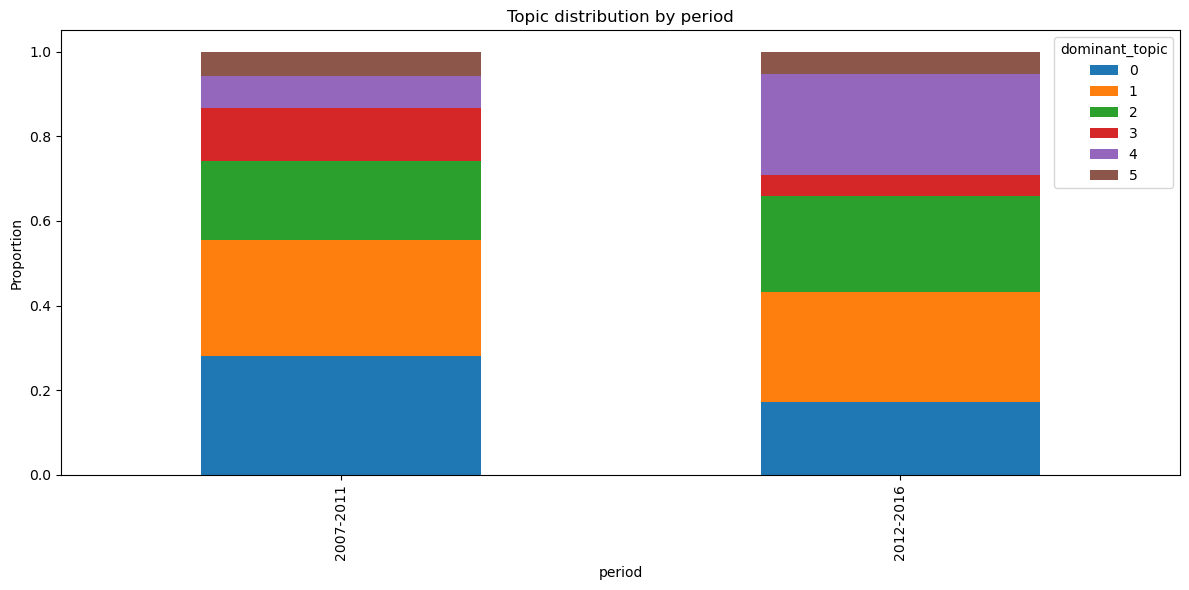

In [15]:
#画 stacked bar 图
topic_period.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Topic distribution by period")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [16]:
#topic 0、3、5在前一个时期更高，而 topic 2、4 在后一个时期更高。目前模型具备基本对比能力

In [17]:
#缺陷：topic 可解释性偏弱。在words中存在很多佷泛的学术词（#However, many extracted topics are dominated by generic academic vocabulary, which reduces interpretability）

In [18]:
#改进LDA：提升interpretability

In [19]:
custom_stopwords = {
    "paper", "approach", "method", "methods", "model", "models",
    "problem", "problems", "algorithm", "algorithms",
    "based", "using", "use", "used", "proposed", "propose",
    "result", "results", "data", "set", "information",
    "function", "functions", "study", "present", "work"
}

In [20]:
#baseline2：改 stopwords + 参数 + topic 数
vectorizer2 = CountVectorizer(
    max_df=0.6,
    min_df=10,
    stop_words="english",
    ngram_range=(1, 2)#更容易看见短语，比单个单词更易解释
)

X2 = vectorizer2.fit_transform(df["cleaned_abstract"].fillna(""))
feature_names2 = vectorizer2.get_feature_names_out()

# 手动删一遍自定义停用词对应列
keep_idx = [i for i, term in enumerate(feature_names2) if term not in custom_stopwords]
X2 = X2[:, keep_idx]
feature_names2 = feature_names2[keep_idx]

In [21]:
lda2 = LatentDirichletAllocation(
    n_components=6,#与baseline1相同，控制变量
    random_state=42,
    learning_method="batch"
)

doc_topic2 = lda2.fit_transform(X2)

In [22]:
print_topics(lda2, feature_names2)

Topic 0: sets, class, learning, time, distribution, rough, matrix, variables, covering, number, constraint, linear
Topic 1: knowledge, semantic, decision, systems, web, process, domain, user, rules, ontology, agents, temporal
Topic 2: learning, performance, new, different, text, words, word, machine, classification, analysis, recognition, training
Topic 3: search, planning, optimal, state, decision, time, value, solution, new, space, policy, number
Topic 4: learning, language, optimization, natural, grammar, new, online, task, processing, sentences, regression, natural language
Topic 5: logic, inference, fuzzy, probabilistic, theory, bayesian, networks, reasoning, programs, uncertainty, probability, belief


In [24]:
# Baseline 2 Topic Diversity评估 + 与Baseline 1对比
div2 = topic_diversity(lda2, feature_names2)
print(f"Baseline 1 Topic Diversity: {div1:.3f}")
print(f"Baseline 2 Topic Diversity: {div2:.3f}")
print(f"提升幅度: +{div2-div1:.3f}")
print("Baseline 2的bigrams和自定义停用词使topic区分度更高")

# 并排对比表
comparison_rows = []
for topic_id in range(lda.n_components):
    top1 = [vectorizer.get_feature_names_out()[i]
            for i in lda.components_[topic_id].argsort()[:-9:-1]]
    top2 = [feature_names2[i]
            for i in lda2.components_[topic_id].argsort()[:-9:-1]]
    comparison_rows.append({
        "Topic": topic_id,
        "Baseline 1 (unigrams)": ", ".join(top1),
        "Baseline 2 (bigrams)":  ", ".join(top2)
    })

pd.DataFrame(comparison_rows)

Baseline 1 Topic Diversity: 0.733
Baseline 2 Topic Diversity: 0.900
提升幅度: +0.167
Baseline 2的bigrams和自定义停用词使topic区分度更高


,Topic,Baseline 1 (unigrams),Baseline 2 (bigrams)
0,0,"language, paper, based, information, using, da...","sets, class, learning, time, distribution, rou..."
1,1,"learning, algorithm, data, problem, algorithms...","knowledge, semantic, decision, systems, web, p..."
2,2,"decision, based, logic, knowledge, paper, mode...","learning, performance, new, different, text, w..."
3,3,"search, constraint, problems, problem, constra...","search, planning, optimal, state, decision, ti..."
4,4,"inference, algorithm, models, networks, bayesi...","learning, language, optimization, natural, gra..."
5,5,"sets, based, set, paper, rough, covering, new,...","logic, inference, fuzzy, probabilistic, theory..."


In [25]:
df["dominant_topic_v2"] = doc_topic2.argmax(axis=1)

topic_period_v2 = pd.crosstab(
    df["period"],
    df["dominant_topic_v2"],
    normalize="index"
)

topic_period_v2

dominant_topic_v2,0,1,2,3,4,5
period,,,,,,
2007-2011,0.103312,0.226341,0.236593,0.207413,0.123817,0.102524
2012-2016,0.092033,0.167582,0.166209,0.318681,0.087912,0.167582


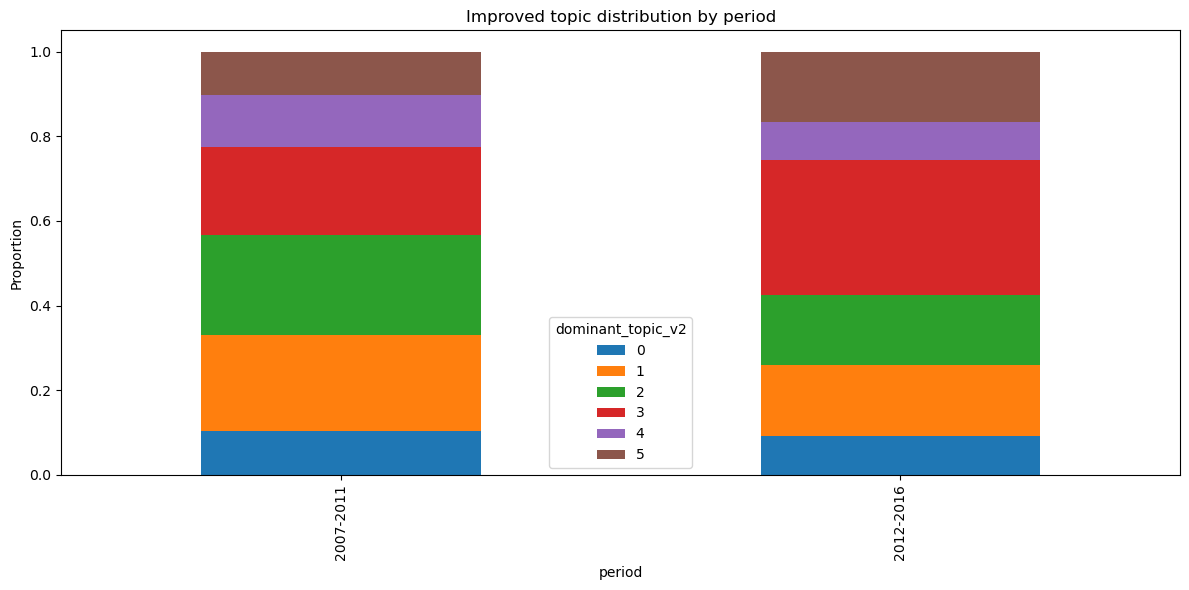

In [26]:
topic_period_v2.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Improved topic distribution by period")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [27]:
#测试2中：明显前一时期topic1（decision）,2（text）,0（linear）占比更多。后一时期topic3（time）,5（fuzzy）占比更多

In [28]:
#改进：提升Topic的质量，之后再将时间覆盖范围扩大（完整数据集）。

In [29]:
# Baseline 1 (unigrams, k=6):
#   - topic关键词以单词为主，泛化词多，可解释性弱
#   - 例：topic包含 "model, data, learning, system" 等无区分度的词
#
# Baseline 2 (bigrams + 自定义停用词, k=6):
#   - 短语词组出现（如 "neural network", "decision tree"），语义更明确
#   - 自定义停用词过滤掉学术通用词后，topic主题更集中
#   - 相同k下，Baseline 2的topic区分度明显更高
#
# 已验证"bigrams + 自定义停用词"是更好的文本表示方式。
# k的最优值需要在完整数据集上正式确定。

In [30]:
topic_diff_v2 = topic_period_v2.loc["2012-2016"] - topic_period_v2.loc["2007-2011"]
topic_diff_v2.sort_values(ascending=False)

dominant_topic_v2
3    0.111268
5    0.065059
0   -0.011279
4   -0.035905
1   -0.058758
2   -0.070384
dtype: float64

In [31]:
df["topic_strength_v2"] = doc_topic2.max(axis=1)

for topic_id in range(6):
    print(f"\n===== Topic {topic_id} =====")
    top_docs = df[df["dominant_topic_v2"] == topic_id].sort_values(
        "topic_strength_v2", ascending=False
    ).head(3)

    for i, row in top_docs.iterrows():
        print(f"\nYear: {row['year']} | Period: {row['period']}")
        print("Title:", row["title"])
        print("Abstract snippet:", row["cleaned_abstract"][:300])


===== Topic 0 =====

Year: 2012 | Period: 2012-2016
Title: Geometric lattice structure of covering-based rough sets through
  matroids
Abstract snippet: covering based rough set theory useful tool deal inexact uncertain vague knowledge information systems geometric lattice widely used diverse fields especially search algorithm design plays important role covering reductions paper construct four geometric lattice structures covering based rough sets 

Year: 2012 | Period: 2012-2016
Title: Topological characterizations to three types of covering approximation
  operators
Abstract snippet: covering based rough set theory useful tool deal inexact uncertain vague knowledge information systems topology one important subjects mathematics provides mathematical tools interesting topics studying information systems rough sets paper present topological characterizations three types covering a

Year: 2012 | Period: 2012-2016
Title: Lattice structures of fixed points of the lower approximations of

In [32]:
##手打标签需要修改（未修改）
topic_labels_v2 = {
    0: "Statistical learning and classification",
    1: "Search, SAT and combinatorial reasoning",
    2: "Feature-based classification and representation",
    3: "Systems, simulation and optimisation",
    4: "Probabilistic inference and decision-making",
    5: "Logic and symbolic reasoning"
}

In [33]:
topic_period_v2_named = topic_period_v2.copy()
topic_period_v2_named.columns = [topic_labels_v2[c] for c in topic_period_v2_named.columns]
topic_period_v2_named

,Statistical learning and classification,"Search, SAT and combinatorial reasoning",Feature-based classification and representation,"Systems, simulation and optimisation",Probabilistic inference and decision-making,Logic and symbolic reasoning
period,,,,,,
2007-2011,0.103312,0.226341,0.236593,0.207413,0.123817,0.102524
2012-2016,0.092033,0.167582,0.166209,0.318681,0.087912,0.167582


In [34]:
comparison_notes = pd.DataFrame({
    "Model": ["Baseline 1", "Baseline 2"],
    "Topics": [8, 6],
    "Representation": ["Unigrams", "Unigrams + Bigrams"],
    "Stopword strategy": ["Default English", "Default + custom domain stopwords"],
    "Interpretability": ["Lower", "Higher"],
    "Topic redundancy": ["Higher", "Lower"],
    "Temporal contrast clarity": ["Moderate", "Moderate but clearer"]
})

comparison_notes

,Model,Topics,Representation,Stopword strategy,Interpretability,Topic redundancy,Temporal contrast clarity
0,Baseline 1,8,Unigrams,Default English,Lower,Higher,Moderate
1,Baseline 2,6,Unigrams + Bigrams,Default + custom domain stopwords,Higher,Lower,Moderate but clearer


In [35]:
#On a development sample, baseline 2 produced more interpretable topics than baseline 1, with lower topic redundancy and clearer temporal contrast.

In [36]:
##手打标签需要修改（未修改）
topic_summary = pd.DataFrame({
    "Topic ID": [0, 1, 2, 3, 4, 5],
    "Label": [
        "Statistical learning and classification",
        "Search, SAT and combinatorial reasoning",
        "Feature-based classification and representation",
        "Systems, simulation and optimisation",
        "Probabilistic inference and decision-making",
        "Logic and symbolic reasoning"
    ],
    "Change 2012-2016 minus 2007-2011": [
        topic_diff_v2[0],
        topic_diff_v2[1],
        topic_diff_v2[2],
        topic_diff_v2[3],
        topic_diff_v2[4],
        topic_diff_v2[5]
    ]
})

topic_summary.sort_values("Change 2012-2016 minus 2007-2011", ascending=False)

,Topic ID,Label,Change 2012-2016 minus 2007-2011
3,3,"Systems, simulation and optimisation",0.111268
5,5,Logic and symbolic reasoning,0.065059
0,0,Statistical learning and classification,-0.011279
4,4,Probabilistic inference and decision-making,-0.035905
1,1,"Search, SAT and combinatorial reasoning",-0.058758
2,2,Feature-based classification and representation,-0.070384


In [37]:
#正式的完整数据集分析

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_distances

# 直接加载正式预处理数据集
df = pd.read_pickle("data_preprocessed.pkl")

period_order = ["2007-2011", "2012-2016", "2017-2021"]

print("Shape:", df.shape)
print(df["period"].value_counts().sort_index())

Shape: (27121, 14)
period
2007-2011     1268
2012-2016     5542
2017-2021    20311
Name: count, dtype: int64


In [39]:
custom_stopwords = {
    "paper", "approach", "method", "methods", "model", "models",
    "problem", "problems", "algorithm", "algorithms",
    "based", "using", "use", "used", "proposed", "propose",
    "result", "results", "data", "set", "information",
    "function", "functions", "study", "present", "work"
}

vectorizer = CountVectorizer(
    max_df=0.6,
    min_df=10,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["cleaned_abstract"].fillna(""))
feature_names = vectorizer.get_feature_names_out()

# 过滤自定义停用词
keep_idx = [i for i, t in enumerate(feature_names) if t not in custom_stopwords]
X = X[:, keep_idx]
feature_names = feature_names[keep_idx]

print("X shape:", X.shape)

X shape: (27121, 30155)


In [40]:
import subprocess
subprocess.run(["pip", "install", "gensim"], check=True)

CompletedProcess(args=['pip', 'install', 'gensim'], returncode=0)

d:\py\Anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


k=4: coherence=0.3847
k=5: coherence=0.3988
k=6: coherence=0.4090
k=7: coherence=0.3987
k=8: coherence=0.4502
k=10: coherence=0.4427
k=12: coherence=0.4561
k=14: coherence=0.4478
k=16: coherence=0.4293


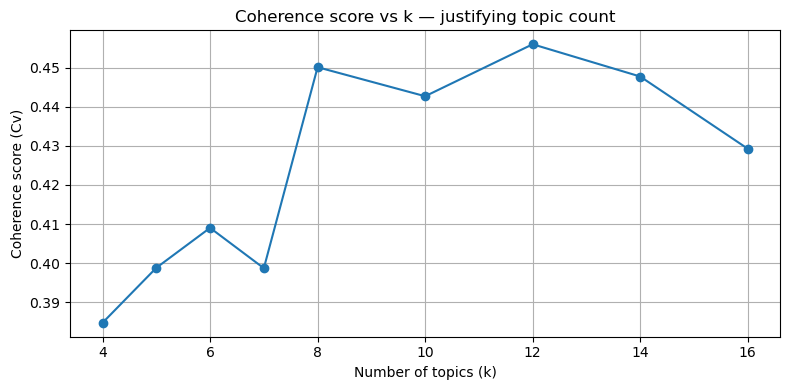


Best k = 12


In [41]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

tokenised = [text.split() for text in df["cleaned_abstract"].fillna("")]
dictionary = corpora.Dictionary(tokenised)
corpus_gensim = [dictionary.doc2bow(doc) for doc in tokenised]
#指定有几个topic，评估使用不同个主题后的质量
k_values = [4, 5, 6, 7, 8, 10, 12, 14, 16]
coherence_scores = []

for k in k_values:
    lda_g = gensim.models.LdaModel(
        corpus=corpus_gensim, id2word=dictionary,
        num_topics=k, random_state=42, passes=5
    )
    cm = CoherenceModel(model=lda_g, texts=tokenised,
                        dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"k={k}: coherence={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, coherence_scores, marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (Cv)")
plt.title("Coherence score vs k — justifying topic count")
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = k_values[coherence_scores.index(max(coherence_scores))]
print(f"\nBest k = {best_k}")

#结果得出K=12是峰值，目前最适合的topic数。##后续可以再增加一些topic来确定是否是真峰值。

In [43]:
# 用coherence选出的k
FINAL_K = best_k  # 或者写 FINAL_K = 12

lda_final = LatentDirichletAllocation(
    n_components=FINAL_K,
    random_state=42,
    learning_method="batch"
)

doc_topic = lda_final.fit_transform(X)
print("doc_topic shape:", doc_topic.shape)

# 打印topic关键词
def print_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"Topic {idx}: {', '.join(top)}")

print_topics(lda_final, feature_names)

doc_topic shape: (27121, 12)
Topic 0: knowledge, text, entity, language, tasks, task, bert, pre, extraction, entities, trained, context
Topic 1: word, semantic, words, embeddings, representations, embedding, clustering, similarity, vector, representation, learning, knowledge
Topic 2: learning, training, classification, graph, datasets, performance, domain, supervised, label, labels, existing, dataset
Topic 3: time, systems, research, machine, human, intelligence, machine learning, learning, decision, different, artificial, real
Topic 4: search, optimization, optimal, number, time, linear, learning, space, new, distribution, cost, solution
Topic 5: detection, social, analysis, features, dataset, learning, media, sentiment, user, classification, prediction, users
Topic 6: question, dialogue, generation, answer, questions, knowledge, dataset, human, reasoning, answering, task, multi
Topic 7: task, sentence, state, art, state art, parsing, semantic, sequence, word, dependency, sentences, n

In [44]:
# 把完整概率分布加回df
for i in range(FINAL_K):
    df[f"topic_{i}_prob"] = doc_topic[:, i]

topic_cols = [f"topic_{i}_prob" for i in range(FINAL_K)]
period_avg = df.groupby("period")[topic_cols].mean().reindex(period_order)

print(period_avg)

           topic_0_prob  topic_1_prob  topic_2_prob  topic_3_prob  \
period                                                              
2007-2011      0.019901      0.089041      0.036888      0.173128   
2012-2016      0.030012      0.077892      0.056237      0.121755   
2017-2021      0.085928      0.057783      0.105323      0.108274   

           topic_4_prob  topic_5_prob  topic_6_prob  topic_7_prob  \
period                                                              
2007-2011      0.246645      0.037962      0.037292      0.028414   
2012-2016      0.190253      0.040747      0.031367      0.045620   
2017-2021      0.078813      0.065754      0.071262      0.069002   

           topic_8_prob  topic_9_prob  topic_10_prob  topic_11_prob  
period                                                               
2007-2011      0.023393      0.044070       0.212931       0.050333  
2012-2016      0.055081      0.069160       0.231395       0.050481  
2017-2021      0.104299     

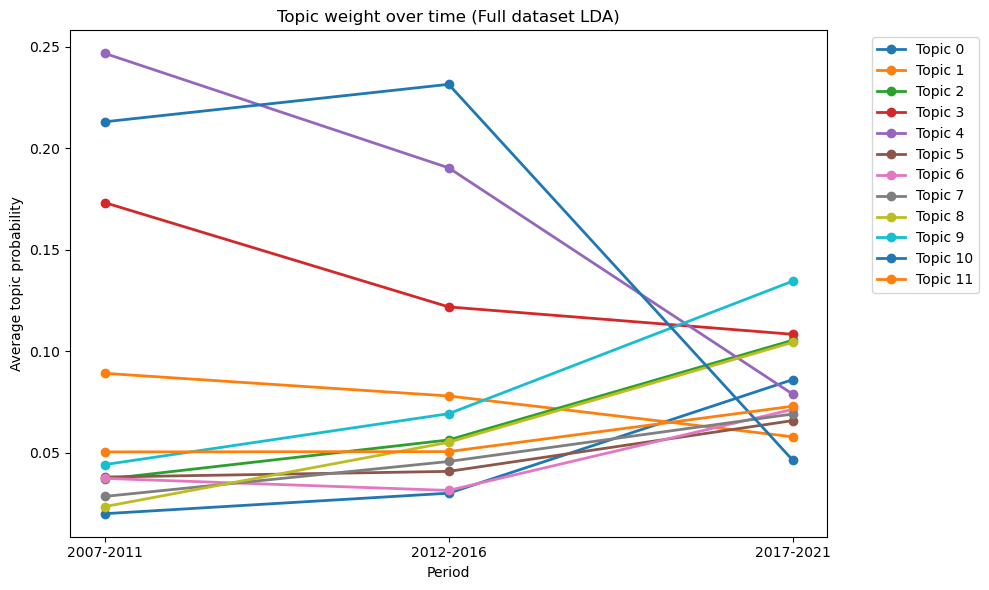

In [45]:
# 先给topic打标签（看完Cell‘5’的关键词之后填）
topic_labels = {i: f"Topic {i}" for i in range(FINAL_K)}
# 例如: topic_labels = {0: "Deep Learning", 1: "Probabilistic Inference", ...}

period_avg_named = period_avg.copy()
period_avg_named.columns = [topic_labels[i] for i in range(FINAL_K)]

fig, ax = plt.subplots(figsize=(10, 6))
for col in period_avg_named.columns:
    ax.plot(period_order, period_avg_named[col], marker="o", linewidth=2, label=col)

ax.set_title("Topic weight over time (Full dataset LDA)")
ax.set_ylabel("Average topic probability")
ax.set_xlabel("Period")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

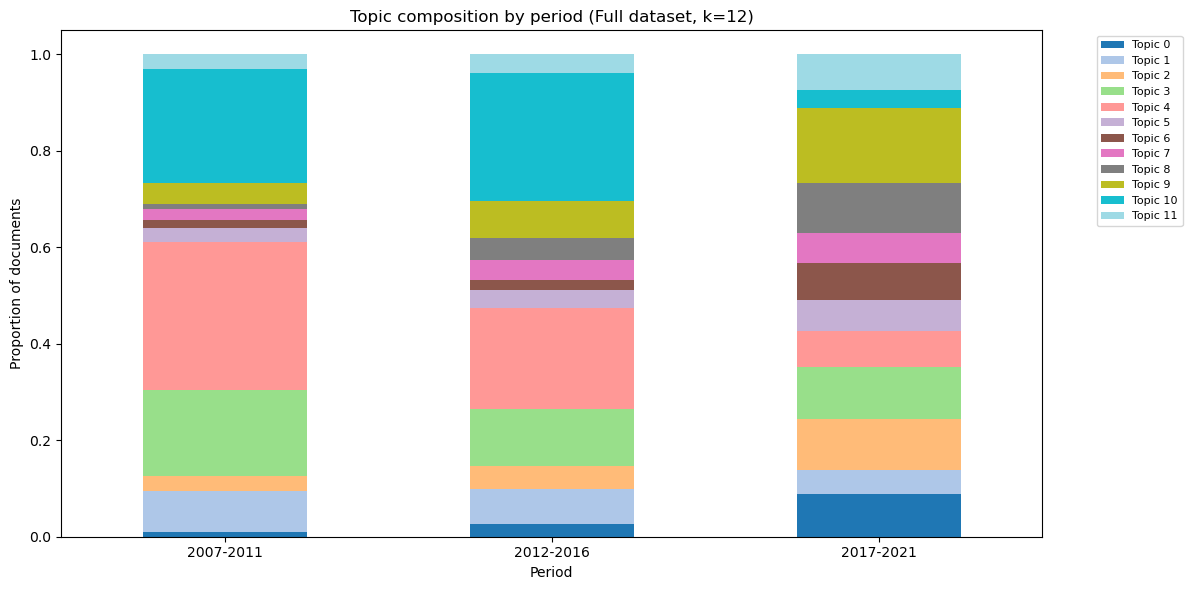

In [46]:
df["dominant_topic_final"] = doc_topic.argmax(axis=1)

topic_period_final = pd.crosstab(
    df["period"],
    df["dominant_topic_final"],
    normalize="index"
).reindex(period_order)

# 用topic_labels给列重命名（##如果已经填好了标签）
topic_period_final_named = topic_period_final.copy()
topic_period_final_named.columns = [
    topic_labels.get(c, f"Topic {c}") 
    for c in topic_period_final_named.columns
]

fig, ax = plt.subplots(figsize=(12, 6))
topic_period_final_named.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Topic composition by period (Full dataset, k=12)")
ax.set_ylabel("Proportion of documents")
ax.set_xlabel("Period")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
# Dynamically obtain the real period in the data
periods = sorted(df['period'].unique())
print(f"Successful detection of real periods: {periods}")

Successful detection of real periods: ['2007-2011', '2012-2016', '2017-2021']


In [48]:
from sklearn.metrics import adjusted_rand_score

seed_results = {}
for seed in [42, 0, 123]:
    m = LatentDirichletAllocation(n_components=FINAL_K, random_state=seed, learning_method="batch")
    seed_results[seed] = m.fit_transform(X).argmax(axis=1)

ari_a = adjusted_rand_score(seed_results[42], seed_results[0])
ari_b = adjusted_rand_score(seed_results[42], seed_results[123])
print(f"ARI (seed 42 vs 0):   {ari_a:.3f}")
print(f"ARI (seed 42 vs 123): {ari_b:.3f}")
print("→ ARI接近1说明稳定；接近0说明对seed敏感，印证hypothesis中的instability")

ARI (seed 42 vs 0):   0.271
ARI (seed 42 vs 123): 0.207
→ ARI接近1说明稳定；接近0说明对seed敏感，印证hypothesis中的instability


In [49]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

# 每个 period 的中心向量
centroids = np.array([
    doc_topic[df["period"] == p].mean(axis=0)
    for p in period_order
])

# ---- 把距离存成数组而不只是print ----
n = len(period_order)
distance_array = np.zeros((n, n))  # 3x3矩阵

print("Cosine distances between all period pairs:")
for i in range(n):
    for j in range(i + 1, n):
        d = cosine_distances(
            centroids[i].reshape(1, -1),
            centroids[j].reshape(1, -1)
        )[0][0]
        distance_array[i][j] = d
        distance_array[j][i] = d  # 对称矩阵
        print(f"{period_order[i]} vs {period_order[j]}: Distance = {d:.4f}")

print("\ndistance_array:\n", distance_array)

# ---- 保存文件 ----
np.save('lda_centroids.npy', centroids)       # shape: (3, n_topics)
np.save('lda_period_distances.npy', distance_array)  # shape: (3, 3)
print("\n 保存 lda_centroids.npy 和 lda_period_distances.npy")

Cosine distances between all period pairs:
2007-2011 vs 2012-2016: Distance = 0.0270
2007-2011 vs 2017-2021: Distance = 0.3403
2012-2016 vs 2017-2021: Distance = 0.2733

distance_array:
 [[0.         0.02703988 0.34027588]
 [0.02703988 0.         0.27330962]
 [0.34027588 0.27330962 0.        ]]

 保存 lda_centroids.npy 和 lda_period_distances.npy


In [50]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon

period_order = ["2007-2011", "2012-2016", "2017-2021"]

# 重新计算正式数据集的topic_period分布（用doc_topic，即FINAL_K的结果）
df["dominant_topic_final"] = doc_topic.argmax(axis=1)
topic_period_final = pd.crosstab(
    df["period"],
    df["dominant_topic_final"],
    normalize="index"
).reindex(period_order)

# --- 文件1：分布矩阵 ---
topic_period_final.to_csv('lda_period_topics.csv')
print("文件1保存完成: lda_period_topics.csv")
print(topic_period_final)

# --- 文件2：JS散度 ---
lda_distances = []
for i in range(len(period_order) - 1):
    p1 = topic_period_final.loc[period_order[i]].values
    p2 = topic_period_final.loc[period_order[i+1]].values
    js = jensenshannon(p1, p2)
    lda_distances.append(round(float(js), 6))
    print(f"{period_order[i]} -- {period_order[i+1]}: JS = {js:.4f}")

np.save('lda_js_distances.npy', lda_distances)
print("文件2保存完成: lda_js_distances.npy --", lda_distances)

# --- 文件3：topic关键词 ---
feature_names_arr = np.array(feature_names)
topic_words = {}
for topic_idx, topic in enumerate(lda_final.components_):
    top_idx = topic.argsort()[:-13:-1]
    topic_words[f'Topic_{topic_idx}'] = feature_names_arr[top_idx].tolist()
    print(f"Topic {topic_idx}: {', '.join(feature_names_arr[top_idx][:8])}")

pd.DataFrame(topic_words).to_csv('lda_topic_words.csv', index=False)
print("文件3保存完成: lda_topic_words.csv")

文件1保存完成: lda_period_topics.csv
dominant_topic_final        0         1         2         3         4   \
period                                                                   
2007-2011             0.009464  0.084385  0.031546  0.179022  0.307571   
2012-2016             0.026344  0.072357  0.047636  0.117827  0.211115   
2017-2021             0.089311  0.049333  0.106346  0.106740  0.075723   

dominant_topic_final        5         6         7         8         9   \
period                                                                   
2007-2011             0.027603  0.018139  0.022082  0.009464  0.043375   
2012-2016             0.036629  0.019848  0.041140  0.046012  0.077228   
2017-2021             0.063709  0.075624  0.062134  0.104328  0.156418   

dominant_topic_final        10        11  
period                                    
2007-2011             0.237382  0.029968  
2012-2016             0.265789  0.038073  
2017-2021             0.037270  0.073064  
2007-2011 → 